# Apple Plant Disease Classification using CNN + AutoTune

This notebook:
- Loads the Apple Disease Dataset
- Uses `tf.data.AUTOTUNE` for efficient data loading
- Uses KerasTuner Hyperband for CNN hyperparameter tuning
- Trains the best CNN
- Evaluates accuracy and confusion matrix
- Saves the trained model
- Allows uploading an Apple leaf image
- Predicts **Apple Scab, Apple Black Rot, Apple Cedar Apple Rust, or Healthy Apple Leaf**


In [1]:
!pip install -q keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 6.2 MB/s eta 0:00:00


In [2]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras_tuner as kt

from google.colab import files
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow:", tf.__version__)
print("Keras Tuner:", kt.__version__)

TensorFlow: 2.20.0
Keras Tuner: 1.4.8


## 1. Download the Apple Disease Dataset

The notebook downloads the Kaggle **Apple Disease Dataset (Original)** automatically.

If the direct Kaggle download does not work, download the ZIP from Kaggle and upload it using the optional cell below.


In [3]:
!wget -q -O apple-disease.zip "https://www.kaggle.com/api/v1/datasets/download/rm1000/apple-disease-dataset-original"

print("Dataset downloaded successfully!")
print("ZIP size:", os.path.getsize("apple-disease.zip") / (1024*1024), "MB")

Dataset downloaded successfully!
ZIP size: 135.13318729400635 MB


In [4]:
# Extract dataset
!rm -rf /content/apple_dataset
!mkdir -p /content/apple_dataset
!unzip -q apple-disease.zip -d /content/apple_dataset

print("Dataset extracted!")

Dataset extracted!


In [5]:
# Inspect extracted structure
for root, dirs, file_list in os.walk("/content/apple_dataset"):
    level = root.replace("/content/apple_dataset", "").count(os.sep)
    if level <= 2:
        print(root)
        for d in dirs:
            print("   ", d)

/content/apple_dataset
    Original Data
/content/apple_dataset/Original Data
    test
    train
/content/apple_dataset/Original Data/test
    Apple___Black_rot
    Apple___Cedar_apple_rust
    Apple___healthy
    Apple___Apple_scab
/content/apple_dataset/Original Data/train
    Apple Scab
    Black Rot
    Cedar Apple Rust
    Healthy


## 2. Locate the Dataset Folder

The code below searches for the folder containing the four Apple class directories.


In [6]:
EXPECTED_CLASSES = {
    "Apple___Apple_scab",
    "Apple___Black_rot",
    "Apple___Cedar_apple_rust",
    "Apple___healthy"
}

DATASET_PATH = None

for root, dirs, file_list in os.walk("/content/apple_dataset"):
    if EXPECTED_CLASSES.issubset(set(dirs)):
        DATASET_PATH = root
        break

if DATASET_PATH is None:
    raise FileNotFoundError(
        "Could not automatically find the four Apple class folders. "
        "Inspect the extracted structure above and set DATASET_PATH manually."
    )

print("Dataset path:", DATASET_PATH)
print("Classes found:", os.listdir(DATASET_PATH))

Dataset path: /content/apple_dataset/Original Data/test
Classes found: ['Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Apple___Apple_scab']


In [7]:
# Count images in each class
for class_name in sorted(EXPECTED_CLASSES):
    class_path = os.path.join(DATASET_PATH, class_name)
    count = sum(
        f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
        for f in os.listdir(class_path)
    )
    print(f"{class_name}: {count} images")

Apple___Apple_scab: 504 images
Apple___Black_rot: 497 images
Apple___Cedar_apple_rust: 440 images
Apple___healthy: 502 images


## 3. Load Training and Validation Data

An 80:20 training-validation split is used.


In [8]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

Found 1943 files belonging to 4 classes.
Using 1555 files for training.
Found 1943 files belonging to 4 classes.
Using 388 files for validation.
Classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy']
Number of classes: 4


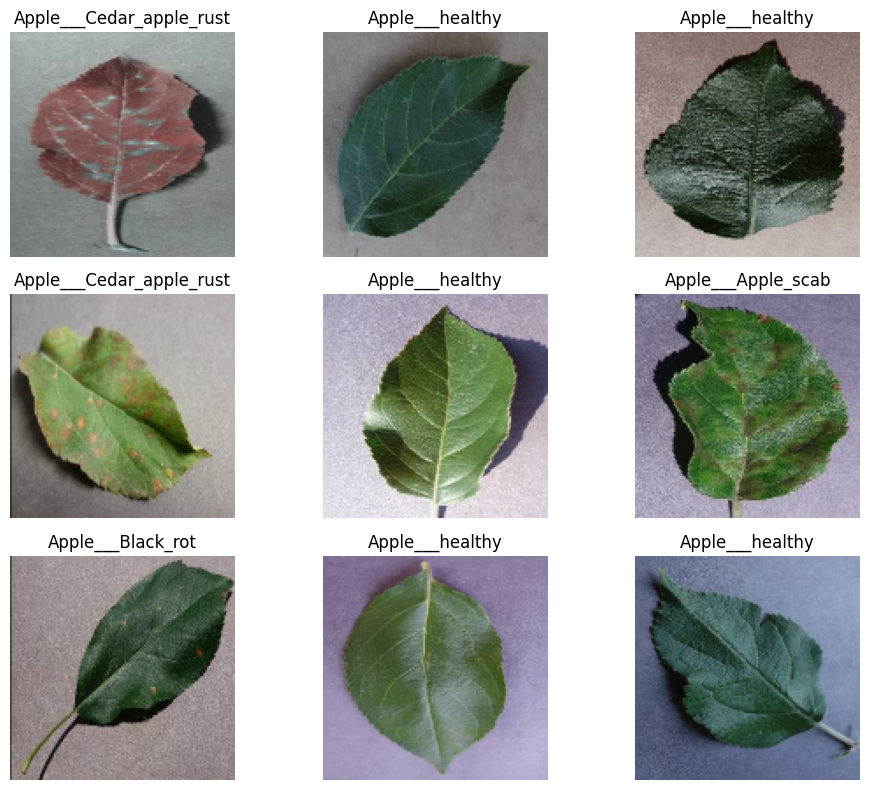

In [9]:
# Display sample images
plt.figure(figsize=(10, 8))

for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

## 4. Use `tf.data.AUTOTUNE`

`AUTOTUNE` lets TensorFlow automatically choose an efficient prefetch configuration.


In [10]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    train_ds
    .cache()
    .shuffle(1000)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .cache()
    .prefetch(AUTOTUNE)
)

print("tf.data.AUTOTUNE enabled!")

tf.data.AUTOTUNE enabled!


In [11]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.10)
])

print("Data augmentation ready.")

Data augmentation ready.


## 5. Build the CNN for KerasTuner

Hyperband will search for:
- convolution filter sizes
- dense layer size
- dropout
- learning rate


In [12]:
def build_model(hp):
    model = models.Sequential([
        layers.Input(shape=(128, 128, 3)),
        data_augmentation,
        layers.Rescaling(1.0 / 255),

        layers.Conv2D(
            filters=hp.Choice("filters_1", [32, 64]),
            kernel_size=(3, 3),
            activation="relu",
            padding="same"
        ),
        layers.MaxPooling2D(),

        layers.Conv2D(
            filters=hp.Choice("filters_2", [64, 128]),
            kernel_size=(3, 3),
            activation="relu",
            padding="same"
        ),
        layers.MaxPooling2D(),

        layers.Conv2D(
            filters=hp.Choice("filters_3", [128, 256]),
            kernel_size=(3, 3),
            activation="relu",
            padding="same"
        ),
        layers.MaxPooling2D(),

        layers.Flatten(),

        layers.Dense(
            units=hp.Choice("dense_units", [128, 256, 512]),
            activation="relu"
        ),

        layers.Dropout(
            hp.Float("dropout", 0.2, 0.5, step=0.1)
        ),

        layers.Dense(num_classes, activation="softmax")
    ])

    learning_rate = hp.Choice(
        "learning_rate",
        [0.001, 0.0005, 0.0001]
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [13]:
tuner = kt.Hyperband(
    build_model,
    objective="val_accuracy",
    max_epochs=10,
    factor=3,
    directory="/content/tuner_results",
    project_name="apple_disease",
    overwrite=True
)

print("Hyperband tuner created.")

Hyperband tuner created.


## 6. Run Hyperparameter AutoTuning


In [34]:
tuner.search(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Trial 30 Complete [00h 00m 32s]
val_accuracy: 0.8582473993301392

Best val_accuracy So Far: 0.9149484634399414
Total elapsed time: 00h 13m 11s


In [35]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("=" * 50)
print("BEST HYPERPARAMETERS")
print("=" * 50)
print("Conv1 filters :", best_hps.get("filters_1"))
print("Conv2 filters :", best_hps.get("filters_2"))
print("Conv3 filters :", best_hps.get("filters_3"))
print("Dense units   :", best_hps.get("dense_units"))
print("Dropout       :", best_hps.get("dropout"))
print("Learning rate :", best_hps.get("learning_rate"))

BEST HYPERPARAMETERS
Conv1 filters : 32
Conv2 filters : 64
Conv3 filters : 256
Dense units   : 512
Dropout       : 0.4
Learning rate : 0.0005


In [36]:
best_model = tuner.get_best_models(num_models=1)[0]

best_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 256)    │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    33,554,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,724,100 (128.65 MB)

 Trainable params: 33,724,100 (128.65 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Train the Best CNN

After Hyperband finds a strong configuration, train that model for additional epochs.


In [37]:
history = best_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.9132 - loss: 0.2391 - val_accuracy: 0.9098 - val_loss: 0.2880
Epoch 2/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.9389 - loss: 0.1676 - val_accuracy: 0.8557 - val_loss: 0.4090
Epoch 3/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.9537 - loss: 0.1404 - val_accuracy: 0.8479 - val_loss: 0.5126
Epoch 4/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.9460 - loss: 0.1486 - val_accuracy: 0.9227 - val_loss: 0.2266
Epoch 5/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.9582 - loss: 0.1166 - val_accuracy: 0.8737 - val_loss: 0.3421
Epoch 6/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.9691 - loss: 0.0838 - val_accuracy: 0.9124 - val_loss: 0.2421
Epoch 7/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.9640 - loss: 0.1090 - val_accuracy: 0.9253 - val_loss: 0.1889
Epoch 8/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.9717 - loss: 0.0823 - val_accuracy: 0.9253 - v

In [38]:
loss, accuracy = best_model.evaluate(val_ds)

print("=" * 50)
print("MODEL PERFORMANCE")
print("=" * 50)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8840 - loss: 0.6590
MODEL PERFORMANCE
Validation Loss: 0.6590
Validation Accuracy: 0.8840 (88.40%)


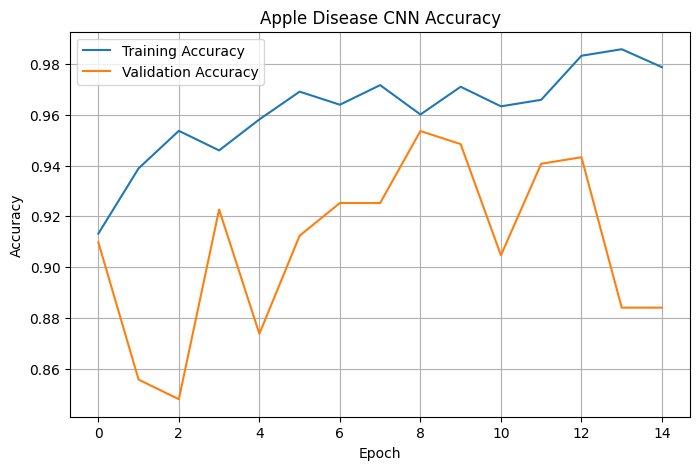

In [41]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Apple Disease CNN Accuracy")
plt.legend()
plt.grid()
plt.show()

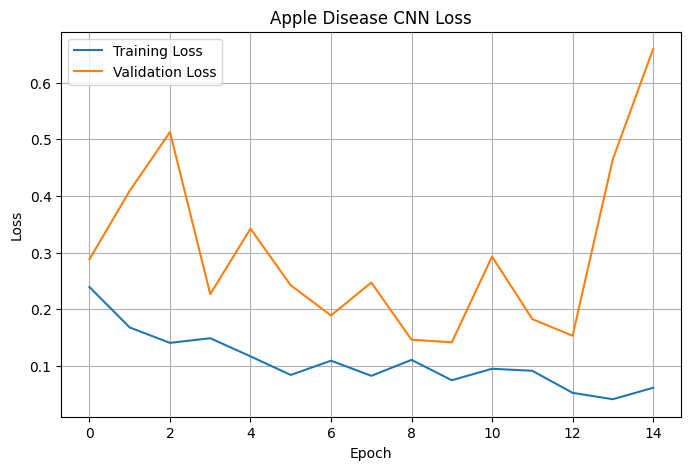

In [42]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Apple Disease CNN Loss")
plt.legend()
plt.grid()
plt.show()

## 8. Classification Report and Confusion Matrix


In [45]:
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = best_model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

                          precision    recall  f1-score   support

      Apple___Apple_scab       0.95      0.78      0.86        91
       Apple___Black_rot       0.71      1.00      0.83        91
Apple___Cedar_apple_rust       0.98      1.00      0.99        94
         Apple___healthy       0.99      0.78      0.87       112

                accuracy                           0.88       388
               macro avg       0.90      0.89      0.89       388
            weighted avg       0.91      0.88      0.89       388



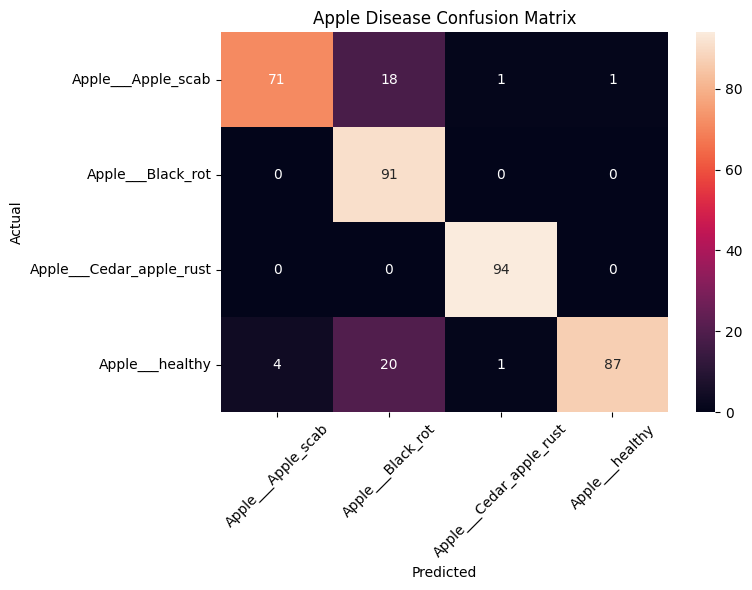

In [46]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Apple Disease Confusion Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 9. Save the Trained Model


In [47]:
MODEL_PATH = "/content/apple_disease_cnn.keras"

best_model.save(MODEL_PATH)

print("Model saved to:", MODEL_PATH)

Model saved to: /content/apple_disease_cnn.keras


## 10. Upload an Apple Leaf Image and Predict the Disease

Supported predictions:
1. Apple Scab
2. Apple Black Rot
3. Apple Cedar Apple Rust
4. Healthy Apple Leaf


In [61]:
uploaded = files.upload()

if not uploaded:
    raise ValueError("No image was uploaded.")

filename = list(uploaded.keys())[0]
print("Uploaded:", filename)

Saving 3.jfif to 3 (2).jfif
Uploaded: 3 (2).jfif


APPLE DISEASE PREDICTION
Disease    : Apple Black Rot
Confidence : 100.00%


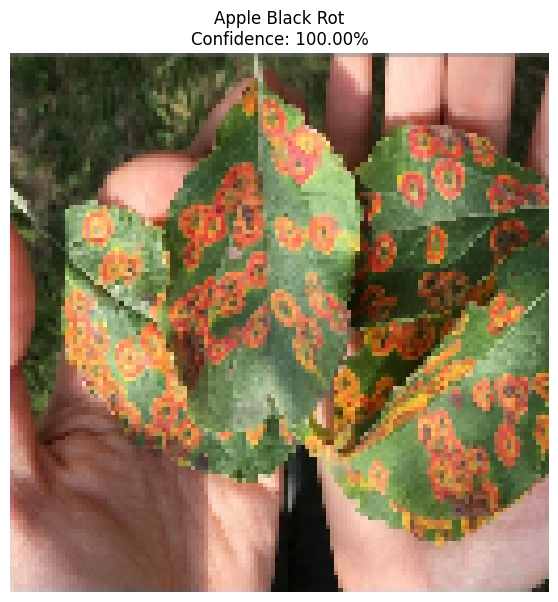

In [62]:
disease_names = {
    "Apple___Apple_scab": "Apple Scab",
    "Apple___Black_rot": "Apple Black Rot",
    "Apple___Cedar_apple_rust": "Apple Cedar Apple Rust",
    "Apple___healthy": "Healthy Apple Leaf"
}

img = tf.keras.utils.load_img(
    filename,
    target_size=IMG_SIZE
)

img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, axis=0)

predictions = best_model.predict(
    img_array,
    verbose=0
)

predicted_index = np.argmax(predictions[0])
predicted_class = class_names[predicted_index]
confidence = float(np.max(predictions[0]) * 100)

predicted_disease = disease_names.get(
    predicted_class,
    predicted_class
)

print("=" * 50)
print("APPLE DISEASE PREDICTION")
print("=" * 50)
print("Disease    :", predicted_disease)
print(f"Confidence : {confidence:.2f}%")
print("=" * 50)

plt.figure(figsize=(7, 7))
plt.imshow(img)
plt.axis("off")
plt.title(
    f"{predicted_disease}\nConfidence: {confidence:.2f}%"
)
plt.show()

## 11. Prediction Probabilities for All Classes

This cell shows the probability assigned to every Apple disease class.


In [63]:
print("Prediction probabilities:")

for class_name, probability in zip(
    class_names,
    predictions[0]
):
    readable_name = disease_names.get(
        class_name,
        class_name
    )
    print(
        f"{readable_name:25s}: {probability * 100:.2f}%"
    )

Prediction probabilities:
Apple Scab               : 0.00%
Apple Black Rot          : 100.00%
Apple Cedar Apple Rust   : 0.00%
Healthy Apple Leaf       : 0.00%
